# 01 — EDA ข้อมูลฝึก (ปทุมธานี 2023–2025)

ใช้เฉพาะข้อมูลฝึก `dataset/processed/train_merged.parquet` (สร้างด้วย `python -m src.preprocess`) ซึ่งเป็นข้อมูลรายชั่วโมงเฉพาะกลางวัน
**notebook นี้ไม่แตะข้อมูลตรวจสอบ TEMIS/OMI เลย**

หมายเหตุเรื่องเวลา: `time_utc` คือเวลาปลายชั่วโมง (NASA POWER ถูกเลื่อน +1 ชม. ให้ตรงกันแล้ว) กราฟจะแสดงเวลาไทย ณ จุดกึ่งกลางชั่วโมง

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
from src.metrics import error_metrics
from src.preprocess import MIDPOINT_OFFSET, estimate_lag_hours, load_raw

df = pd.read_parquet(ROOT / "dataset" / "processed" / "train_merged.parquet")
mid_local = (df["time_utc"] + MIDPOINT_OFFSET).dt.tz_convert("Asia/Bangkok")
df["hour_local"] = mid_local.dt.hour + mid_local.dt.minute / 60
df["date_local"] = mid_local.dt.date
df["month"] = mid_local.dt.month
SEASON = {3: "Hot", 4: "Hot", 5: "Hot", 6: "Rainy", 7: "Rainy", 8: "Rainy", 9: "Rainy",
          10: "Rainy", 11: "Cool", 12: "Cool", 1: "Cool", 2: "Cool"}
df["season"] = df["month"].map(SEASON)
print(len(df), "daytime rows")
df.describe().T.round(2)

13280 daytime rows


,count,mean,std,min,25%,50%,75%,max
uv_index,13280.0,3.79,2.81,0.00,1.10,3.40,6.30,9.30
uv_index_clear_sky,13280.0,4.63,2.96,0.05,1.65,5.05,7.25,9.30
cloud_cover,13280.0,73.27,35.50,0.00,44.00,97.00,100.00,100.00
relative_humidity_2m,13280.0,65.44,15.65,21.00,54.00,66.00,77.00,99.00
temperature_2m,13280.0,30.31,3.09,17.90,28.20,30.30,32.30,41.10
aerosol_optical_depth,13280.0,0.46,0.34,0.05,0.23,0.35,0.58,4.52
dust,13280.0,1.04,3.07,0.00,0.00,0.00,1.00,62.00
pm2_5,13280.0,30.04,21.31,3.20,16.10,24.40,37.80,382.80
ozone,13280.0,112.19,73.72,0.00,56.00,97.00,155.00,399.00
nasa_uva_wm2,13280.0,25.45,16.39,0.05,10.00,25.98,40.04,61.82


## 1. UVI ตามชั่วโมงของวัน (ค่าเฉลี่ย 3 ปี)

,uv_index,uv_index_clear_sky,nasa_uvi
hour_local,,,
6.5,0.21,0.28,0.03
7.5,1.11,1.38,0.40
8.5,2.72,3.30,1.75
9.5,4.50,5.36,4.03
10.5,6.03,7.09,6.22
11.5,7.02,8.17,7.88
12.5,7.10,8.43,8.45
13.5,6.38,7.83,7.29
14.5,5.03,6.47,5.21


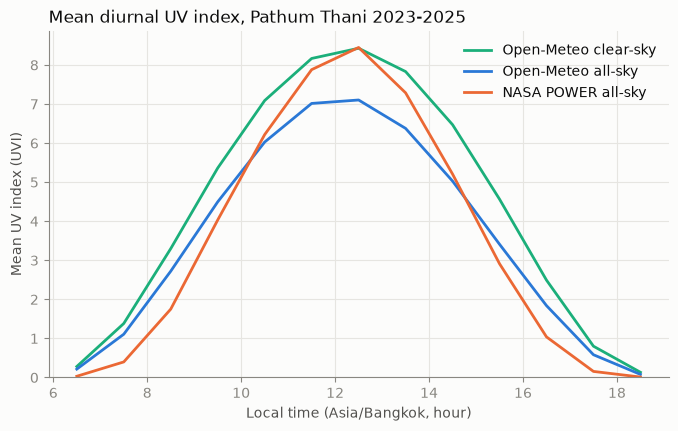

In [3]:
hourly = df.groupby("hour_local")[["uv_index", "uv_index_clear_sky", "nasa_uvi"]].mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hourly.index, hourly["uv_index_clear_sky"], color=C_THIRD, label="Open-Meteo clear-sky")
ax.plot(hourly.index, hourly["uv_index"], color=C_OM, label="Open-Meteo all-sky")
ax.plot(hourly.index, hourly["nasa_uvi"], color=C_NASA, label="NASA POWER all-sky")
ax.set_xlabel("Local time (Asia/Bangkok, hour)")
ax.set_ylabel("Mean UV index (UVI)")
ax.set_title("Mean diurnal UV index, Pathum Thani 2023-2025", loc="left")
ax.set_xticks(range(6, 20, 2))
ax.set_ylim(0, None)
ax.legend(loc="upper right")
save(fig, "eda_diurnal_uvi.png")
hourly.round(2)

## 2. UVI ตามเดือน (ค่าเฉลี่ยของค่าสูงสุดรายวัน)

,uv_index_clear_sky,uv_index,nasa_uvi
month,,,
1,7.29,7.03,7.73
2,8.21,7.98,8.22
3,9.00,8.80,8.90
4,9.23,8.86,9.39
5,9.03,8.31,9.13
6,8.88,7.19,9.34
7,8.96,6.50,8.71
8,9.12,7.89,9.55
9,8.93,7.47,8.81


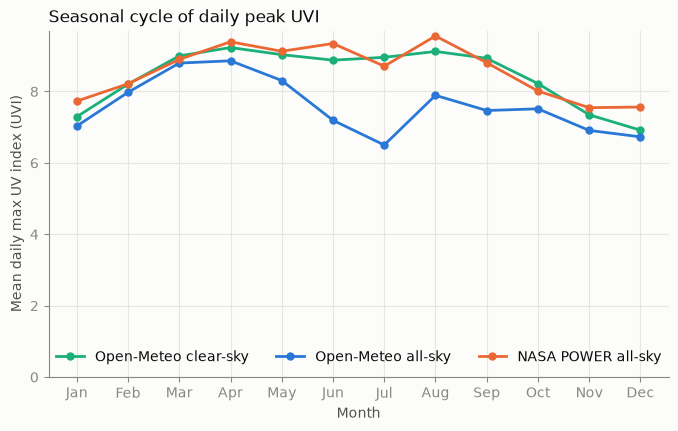

In [4]:
daily_max = df.groupby("date_local").agg(
    uv_index=("uv_index", "max"), nasa_uvi=("nasa_uvi", "max"),
    uv_index_clear_sky=("uv_index_clear_sky", "max"), month=("month", "first"),
    season=("season", "first"))
monthly = daily_max.groupby("month")[["uv_index_clear_sky", "uv_index", "nasa_uvi"]].mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(monthly.index, monthly["uv_index_clear_sky"], color=C_THIRD, marker="o", ms=5, label="Open-Meteo clear-sky")
ax.plot(monthly.index, monthly["uv_index"], color=C_OM, marker="o", ms=5, label="Open-Meteo all-sky")
ax.plot(monthly.index, monthly["nasa_uvi"], color=C_NASA, marker="o", ms=5, label="NASA POWER all-sky")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily max UV index (UVI)")
ax.set_title("Seasonal cycle of daily peak UVI", loc="left")
ax.set_ylim(0, None)
ax.legend(loc="lower center", ncols=3)
save(fig, "eda_monthly_uvi.png")
monthly.round(2)

## 3. UVI ตามฤดู (ร้อน มี.ค.–พ.ค. / ฝน มิ.ย.–ต.ค. / หนาว พ.ย.–ก.พ.)

uv_index                                           nasa_uvi        \
          count  mean   std   min   25%   50%   75%   max    count  mean   
season                                                                     
Cool      361.0  7.15  0.79  3.45  6.85  7.10  7.55  8.65    361.0  7.76   
Hot       276.0  8.65  0.89  3.00  8.60  8.95  9.15  9.30    276.0  9.14   
Rainy     459.0  7.31  1.72  0.90  6.72  7.90  8.55  9.20    459.0  8.88   

                                              
         std   min   25%   50%    75%    max  
season                                        
Cool    0.92  4.53  7.28  7.82   8.30  10.07  
Hot     1.44  4.30  8.44  9.40  10.13  11.82  
Rainy   1.41  4.38  7.86  8.90   9.84  12.85

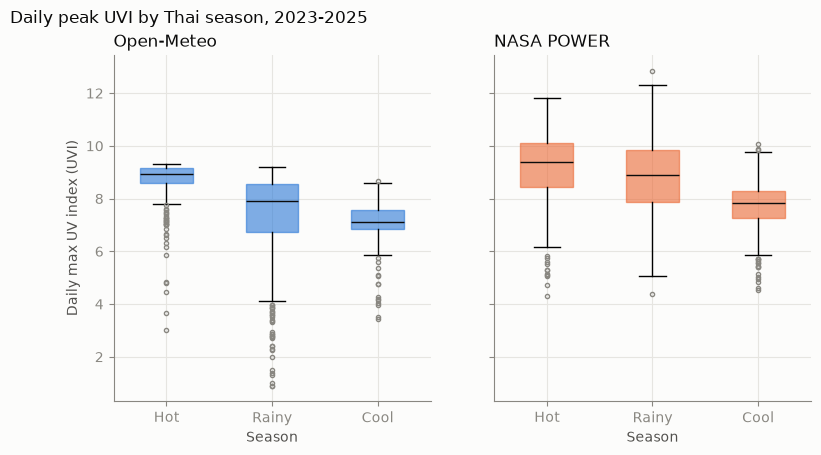

In [5]:
order = ["Hot", "Rainy", "Cool"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)
for ax, col, color, name in [(axes[0], "uv_index", C_OM, "Open-Meteo"),
                             (axes[1], "nasa_uvi", C_NASA, "NASA POWER")]:
    data = [daily_max.loc[daily_max["season"] == s, col] for s in order]
    bp = ax.boxplot(data, tick_labels=order, patch_artist=True, widths=0.5,
                    medianprops={"color": INK}, flierprops={"markersize": 3, "markeredgecolor": MUTED})
    for box in bp["boxes"]:
        box.set_facecolor(color); box.set_alpha(0.6); box.set_edgecolor(color)
    ax.set_title(name, loc="left")
    ax.set_xlabel("Season")
axes[0].set_ylabel("Daily max UV index (UVI)")
fig.suptitle("Daily peak UVI by Thai season, 2023-2025", x=0.01, ha="left")
save(fig, "eda_season_uvi.png")
daily_max.groupby("season")[["uv_index", "nasa_uvi"]].describe().round(2)

## 4. Correlation heatmap

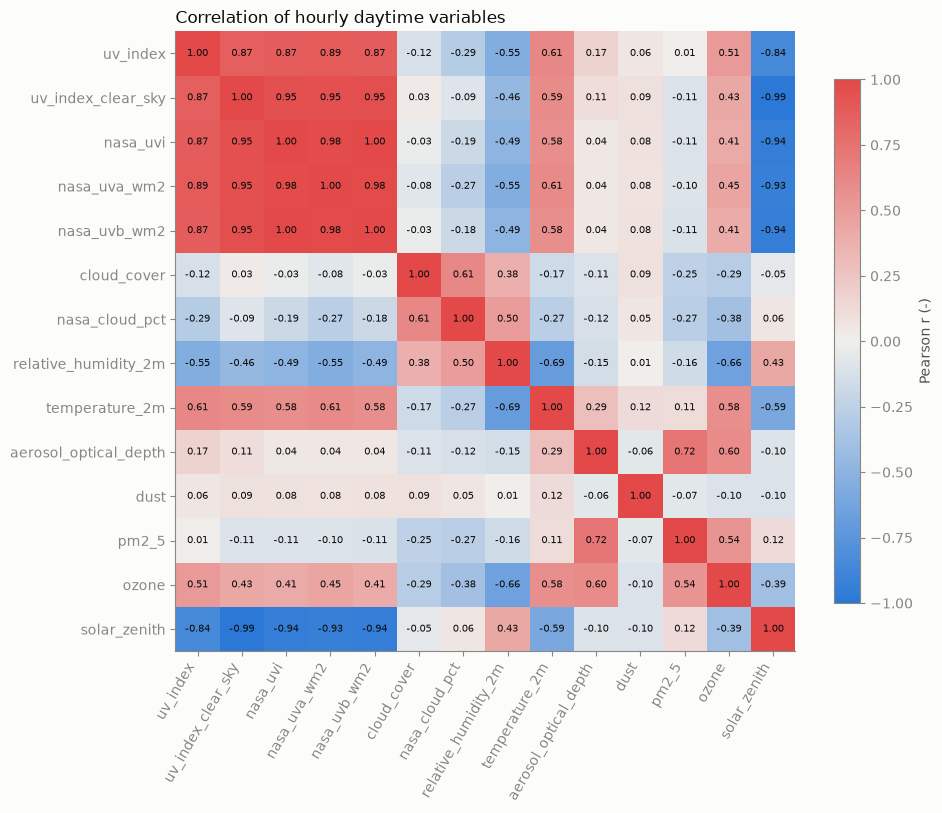

In [6]:
cols = ["uv_index", "uv_index_clear_sky", "nasa_uvi", "nasa_uva_wm2", "nasa_uvb_wm2",
        "cloud_cover", "nasa_cloud_pct", "relative_humidity_2m", "temperature_2m",
        "aerosol_optical_depth", "dust", "pm2_5", "ozone", "solar_zenith"]
corr = df[cols].corr()
div = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr, cmap=div, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=60, ha="right")
ax.set_yticks(range(len(cols)), cols)
ax.grid(False)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7, color=INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r (-)")
ax.set_title("Correlation of hourly daytime variables", loc="left")
save(fig, "eda_correlation.png")

## 5. เทียบ Open-Meteo กับ NASA POWER
เป็นการเทียบแหล่งข้อมูลฝึกสองแหล่งกันเอง ยังไม่มีแหล่งใดเป็นค่าจริง ส่วนการเลือกแหล่งที่จะใช้เป็น target อยู่ใน `02_source_selection.ipynb`

NASA POWER vs Open-Meteo (hourly, daytime): {'n': 13280, 'mae': 1.09, 'bias': -0.045, 'rmse': 1.563, 'r': 0.871}


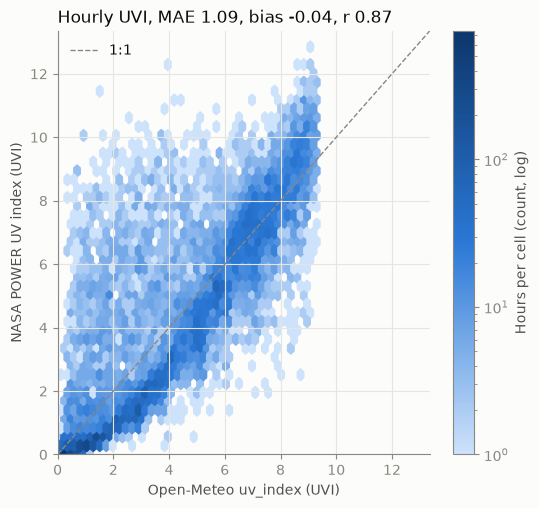

In [7]:
m = error_metrics(df["nasa_uvi"], df["uv_index"])
print("NASA POWER vs Open-Meteo (hourly, daytime):", {k: round(v, 3) for k, v in m.items()})

fig, ax = plt.subplots(figsize=(6, 5.5))
hb = ax.hexbin(df["uv_index"], df["nasa_uvi"], gridsize=40, mincnt=1, bins="log",
               cmap=LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"]))
lim = max(df["uv_index"].max(), df["nasa_uvi"].max()) + 0.5
ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--", label="1:1")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Open-Meteo uv_index (UVI)")
ax.set_ylabel("NASA POWER UV index (UVI)")
ax.set_title(f"Hourly UVI, MAE {m['mae']:.2f}, bias {m['bias']:+.2f}, r {m['r']:.2f}", loc="left")
fig.colorbar(hb, ax=ax, label="Hours per cell (count, log)")
ax.legend(loc="upper left")
save(fig, "eda_om_vs_nasa.png")

### Lag ของ timestamp (ข้อมูลดิบก่อนเลื่อนเวลา)
ถ้า lag ที่ได้ค่า r สูงสุดคือ +1 ชม. แสดงว่าต้องเลื่อน NASA POWER +1 ชม. (label ต้นชั่วโมง → ปลายชั่วโมง) ซึ่งตรงกับ `POWER_SHIFT_HOURS` ใน `src/preprocess.py`

{-3: np.float64(0.2124),
 -2: np.float64(0.4751),
 -1: np.float64(0.7121),
 0: np.float64(0.8744),
 1: np.float64(0.9255),
 2: np.float64(0.8546),
 3: np.float64(0.6783)}

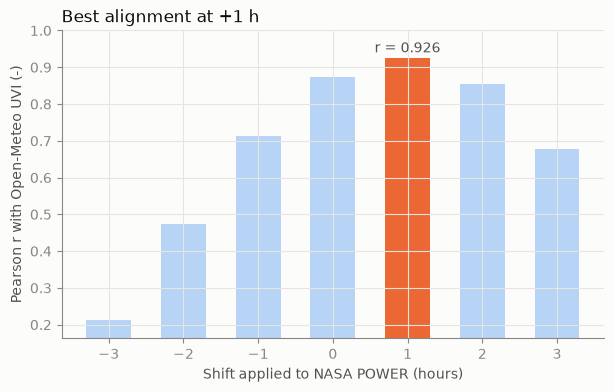

In [8]:
weather, air, power = load_raw()
a = weather.set_index("time_utc")["uv_index"]
b = power.set_index("time_utc")["ALLSKY_SFC_UV_INDEX"]
lags = list(range(-3, 4))
r = [a.corr(b.shift(k, freq="h").reindex(a.index)) for k in lags]
best = estimate_lag_hours(a, b, max_lag=3)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(lags, r, color=[C_NASA if k == best else "#b7d3f6" for k in lags], width=0.6)
ax.set_xlabel("Shift applied to NASA POWER (hours)")
ax.set_ylabel("Pearson r with Open-Meteo UVI (-)")
ax.set_ylim(min(r) - 0.05, 1)
ax.set_title(f"Best alignment at {best:+d} h", loc="left")
ax.annotate(f"r = {max(r):.3f}", (best, max(r)), textcoords="offset points", xytext=(0, 4), ha="center", color=INK2)
save(fig, "eda_lag.png")
dict(zip(lags, np.round(r, 4)))

## สรุป
- ใช้ข้อมูลกลางวันทั้งหมด 13,280 ชั่วโมง ตัดทิ้งเพียง 6 แถวในขั้นทำความสะอาด (ค่า ozone ที่ผิดปกติหรือค่าที่ขาดหายนานกว่า 3 ชม.)
- ดูตารางและกราฟด้านบนสำหรับรูปแบบรายชั่วโมง รายเดือน และรายฤดู รวมถึงความต่างระหว่าง Open-Meteo กับ NASA POWER (MAE / bias)
- การเลือกว่าจะใช้แหล่งใดเป็น target ทำใน `02_source_selection.ipynb` โดยใช้ TEMIS/OMI เฉพาะปี 2023